In [1]:
import warnings

# 모든 경고 무시
warnings.filterwarnings("ignore")


=== 출산율과 상관관계 ===
출산율                    1.000000
혼인율(남성)                0.979684
혼인율(여성)                0.782962
비경제활동인구 (천명)           0.217939
실업률 (%)                0.060340
경제성장률                  0.050365
소비자심리지수                0.049386
실업자 (천명)              -0.012686
소비자물가지수(CPI)          -0.156309
국내총생산(GDP) 단위 : 10억   -0.164299
취업자 (천명)              -0.458987
경제활동인구 (천명)           -0.501383
고용률 (%)               -0.521917
경제활동참가율 (%)           -0.543816
Name: 출산율, dtype: float64

=== Bartlett Test: 출산율 vs 다른 변수들의 등분산 검정 ===
혼인율(남성): stat=37.385, p=0.0000
혼인율(여성): stat=19.483, p=0.0000
경제활동인구 (천명): stat=294.253, p=0.0000
취업자 (천명): stat=311.004, p=0.0000
실업자 (천명): stat=1.142, p=0.2852
비경제활동인구 (천명): stat=231.193, p=0.0000
경제활동참가율 (%): stat=306.467, p=0.0000
실업률 (%): stat=424.812, p=0.0000
고용률 (%): stat=296.886, p=0.0000
국내총생산(GDP) 단위 : 10억: stat=1732.916, p=0.0000
경제성장률: stat=737.458, p=0.0000
소비자심리지수: stat=180.970, p=0.0000
소비자물가지수(CPI): stat=155.902, p=0.0000


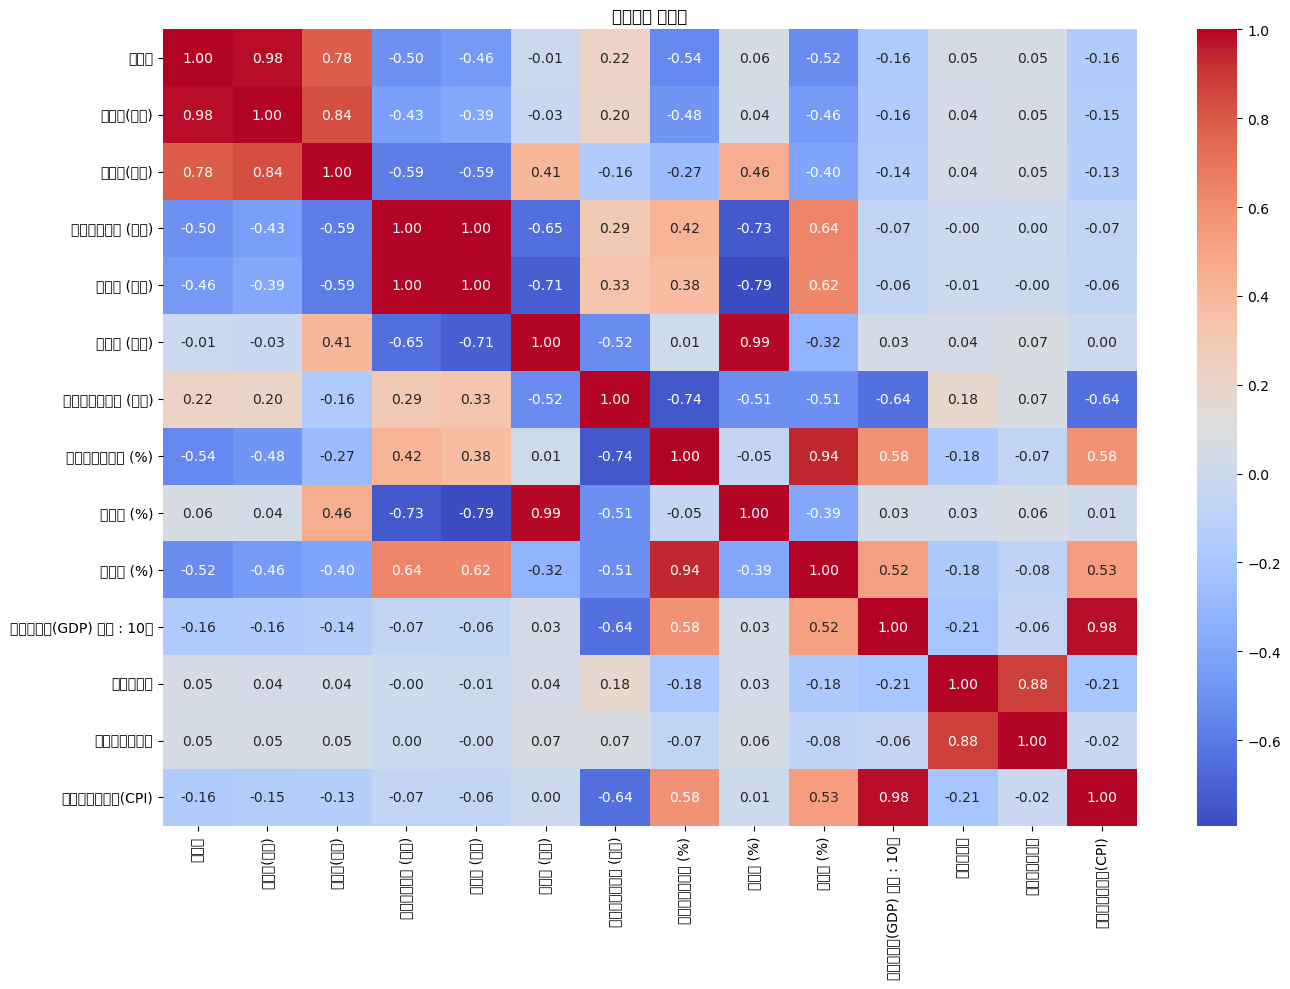


=== 출산율과 상관계수 TOP 5 ===
혼인율(남성)        0.979684
혼인율(여성)        0.782962
경제활동참가율 (%)    0.543816
고용률 (%)        0.521917
경제활동인구 (천명)    0.501383
Name: 출산율, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, bartlett
import seaborn as sns

# ================================
# 1. CSV 로드 (파일명 수정해서 사용)
# ================================
df = pd.read_csv("dataframe.csv")

# ================================
# 2. 숫자형 변환 (천 단위 콤마 제거)
# ================================
cols_to_clean = [
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)", 
    "비경제활동인구 (천명)", "국내총생산(GDP) 단위 : 10억",
]

for c in cols_to_clean:
    df[c] = df[c].astype(str).str.replace(",", "").astype(float)

# ================================
# 3. 필요한 분석용 컬럼 선택
# ================================
analysis_cols = [
    "출산율",
    "혼인율(남성)", "혼인율(여성)",
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)",
    "비경제활동인구 (천명)",
    "경제활동참가율 (%)", "실업률 (%)", "고용률 (%)",
    "국내총생산(GDP) 단위 : 10억",
    "경제성장률", "소비자심리지수", "소비자물가지수(CPI)"
]

df_analysis = df[analysis_cols].dropna()

# ================================
# 4. 상관계수 테이블 생성
# ================================
corr_table = df_analysis.corr(method="pearson")
print("=== 출산율과 상관관계 ===")
print(corr_table["출산율"].sort_values(ascending=False))

# ================================
# 5. Bartlett 등분산 검정
# ================================
print("\n=== Bartlett Test: 출산율 vs 다른 변수들의 등분산 검정 ===")
for col in analysis_cols:
    if col == "출산율":
        continue
    try:
        stat, p = bartlett(df_analysis["출산율"], df_analysis[col])
        print(f"{col}: stat={stat:.3f}, p={p:.4f}")
    except:
        print(f"{col}: 계산 불가")

# ================================
# 6. Heatmap 시각화
# ================================
plt.figure(figsize=(14, 10))
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상관관계 히트맵")
plt.tight_layout()
plt.show()

# ================================
# 7. 출산율과 가장 강한 상관 변수 TOP 5
# ================================
top5 = corr_table["출산율"].abs().sort_values(ascending=False)[1:6]
print("\n=== 출산율과 상관계수 TOP 5 ===")
print(top5)


사용되는 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)', '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)', '국내총생산(GDP) 단위 : 10억', '경제성장률', '소비자심리지수', '소비자물가지수(CPI)']

=== 정상성 검정 (ADF) ===
출산율: 정상성 없음 (p=0.9345) → 차분 적용
혼인율(남성): 정상성 없음 (p=0.4058) → 차분 적용
혼인율(여성): 정상성 없음 (p=0.4283) → 차분 적용
경제활동인구 (천명): 정상성 없음 (p=0.2458) → 차분 적용
취업자 (천명): 정상성 없음 (p=0.2649) → 차분 적용
실업자 (천명): 정상성 없음 (p=0.6773) → 차분 적용
비경제활동인구 (천명): 정상성 없음 (p=0.9973) → 차분 적용
경제활동참가율 (%): 정상성 없음 (p=0.9917) → 차분 적용
실업률 (%): 정상성 없음 (p=0.7792) → 차분 적용
고용률 (%): 정상성 없음 (p=0.9921) → 차분 적용
국내총생산(GDP) 단위 : 10억: 정상성 없음 (p=0.9965) → 차분 적용
경제성장률: 정상성 없음 (p=0.3060) → 차분 적용
소비자심리지수: 정상성 없음 (p=0.5031) → 차분 적용
소비자물가지수(CPI): 정상성 없음 (p=0.9492) → 차분 적용

정상성 확보 후 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)', '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)', '국내총생산(GDP) 단위 : 10억', '경제성장률', '소비자심리지수', '소비자물가지수(CPI)']

=== 출산율 상관관계 ===
출산율                    1.000000
혼인율(남성)                0.95

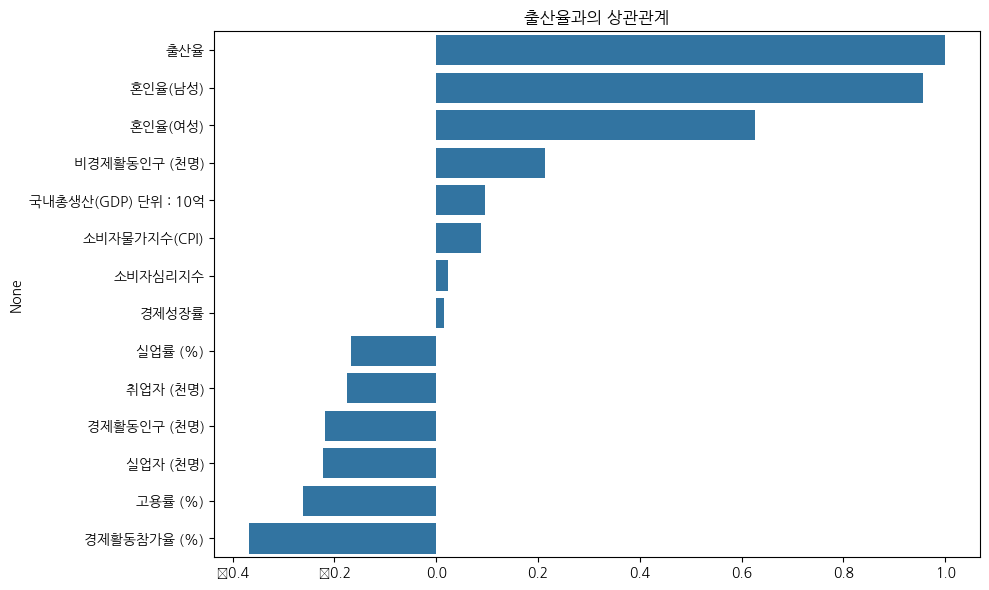


=== Granger Causality Test ===

[ 혼인율(남성) → 출산율 ]
lag=1 p-value = 0.0001

[ 혼인율(여성) → 출산율 ]
lag=1 p-value = 0.0000

[ 경제활동인구 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 취업자 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 실업자 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 비경제활동인구 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 경제활동참가율 (%) → 출산율 ]
lag=1 p-value = 0.0183

[ 실업률 (%) → 출산율 ]
lag=1 p-value = 0.0000

[ 고용률 (%) → 출산율 ]
lag=1 p-value = 0.2975

[ 국내총생산(GDP) 단위 : 10억 → 출산율 ]
lag=1 p-value = 0.0001

[ 경제성장률 → 출산율 ]
lag=1 p-value = 0.5459

[ 소비자심리지수 → 출산율 ]
lag=1 p-value = 0.3505

[ 소비자물가지수(CPI) → 출산율 ]
lag=1 p-value = 0.0003


In [3]:
# ==================================================
# 1) 데이터 로드 & 숫자 클린업 (안전한 방식)
# ==================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.preprocessing import StandardScaler

plt.rc('font', family='NanumGothic')

df = pd.read_csv("dataframe.csv")

# ---- 숫자만 남기기 ----
def clean_str_to_num(val):
    if isinstance(val, str):
        val = re.sub(r"[^0-9.\-]", "", val)
    return val

df = df.map(clean_str_to_num)
df = df.apply(pd.to_numeric, errors="coerce")

# ---------------------------------------------
# 2) 필요한 컬럼만 선택 (중요)
# ---------------------------------------------
target = "출산율"

candidate_cols = [
    "출산율",
    "혼인율(남성)", "혼인율(여성)",
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)",
    "비경제활동인구 (천명)",
    "경제활동참가율 (%)", "실업률 (%)", "고용률 (%)",
    "국내총생산(GDP) 단위 : 10억",
    "경제성장률", "소비자심리지수", "소비자물가지수(CPI)"
]

df = df[candidate_cols].dropna(how="all", axis=1)

print(f"사용되는 컬럼: {df.columns.tolist()}\n")

# ==================================================
# 3) 정상성 확보 (ADF + 차분) + 예외 처리
# ==================================================

def safe_adf(series):
    s = series.dropna()
    if len(s) < 5:
        return None, None  # insufficient data
    if s.max() == s.min():
        return None, None  # constant series
    try:
        result = adfuller(s)
        p = result[1]
        return result, p
    except:
        return None, None

df_stationary = pd.DataFrame()

print("=== 정상성 검정 (ADF) ===")
for col in df.columns:
    r, p = safe_adf(df[col])

    if p is None:
        print(f"{col}: 데이터 부족/상수 → 제거")
        continue

    if p < 0.05:
        print(f"{col}: 정상성 있음 (p={p:.4f}) → 원본 사용")
        df_stationary[col] = df[col]
    else:
        print(f"{col}: 정상성 없음 (p={p:.4f}) → 차분 적용")
        df_stationary[col] = df[col].diff()

df_stationary = df_stationary.dropna()

print("\n정상성 확보 후 컬럼:", df_stationary.columns.tolist())

# ==================================================
# 4) 표준화
# ==================================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_stationary),
    index=df_stationary.index,
    columns=df_stationary.columns
)

# ==================================================
# 5) 상관관계 분석
# ==================================================

corr = df_scaled.corr()[target].sort_values(ascending=False)
print("\n=== 출산율 상관관계 ===")
print(corr)

plt.figure(figsize=(10, 6))
sns.barplot(y=corr.index, x=corr.values)
plt.title("출산율과의 상관관계")
plt.tight_layout()
plt.show()

# ==================================================
# 6) Granger Causality Test
# ==================================================
print("\n=== Granger Causality Test ===")

maxlag = 2

for col in df_stationary.columns:
    if col == target:
        continue

    print(f"\n[ {col} → 출산율 ]")
    try:
        g = grangercausalitytests(
            df_stationary[[target, col]], 
            maxlag=maxlag, 
            verbose=False
        )
        p = g[1][0]["ssr_ftest"][1]
        print(f"lag=1 p-value = {p:.4f}")
    except Exception as e:
        print("테스트 불가:", e)


1. 출산율 vs 주요 변수 — 상관관계 결과 해석

상관계수는 “같은 방향으로 움직이는 정도”를 말하며
+1에 가까울수록 강한 양의 상관,
–1에 가까울수록 강한 음의 상관이야.

정리하면 아래와 같아.

✅ 강한 양의 상관관계
1) 혼인율(남성) → 0.956 (매우 강함)
2) 혼인율(여성) → 0.626 (강함)

➡️ 결혼 관련 지표와 출산율의 상관은 압도적으로 높다.

📌 해석

한국의 출산 구조는 “결혼 출산” 중심이다.

혼인율이 떨어지면 그 자체로 출산 기회가 줄어든다.

특히 남성 혼인율과 여성 혼인율은 서로 밀접한데,
남성 혼인율이 여성보다 출산율과 더 높은 상관을 보인 것은
남성 혼인율이 경기·취업·경제 변수의 영향을 더 직접 받기 때문이다.

🟨 약한 양의 상관관계

비경제활동인구 (0.21)

GDP (0.09)

CPI (0.087)

소비자심리지수 (0.024)

경제성장률 (0.015)

➡️ 출산율과 큰 관계가 없는 변수들.

📌 해석
GDP·성장률·물가지수 같은 거시경제 지표는
출산율을 단기적으로 움직이는 데 영향이 거의 없다.
출산은 개인·가정 단위의 의사결정이라
GDP가 올랐다고 갑자기 애를 낳지 않는다.

🔻 음의 상관관계(출산율과 반대로 움직임)
중간 정도의 음의 상관

경제활동참가율(–0.367)

고용률(–0.260)

약한 음의 상관

실업자(–0.22)

경제활동인구(–0.21)

취업자(–0.17)

실업률(–0.16)

📌 해석
이 부분은 매우 흥미로운데:

여성 경제활동 증가 → 출산율 감소
한국 여성은 경력단절 위험이 높기 때문에
경제활동참가율이 증가할수록 출산을 미루거나 포기하는 경향이 강하다.

고용률 증가도 출산율 감소와 연결
고용률 상승은 “일하는 사람 증가”를 의미하지만
한국에서는

장시간 노동

낮은 육아지원

맞벌이 부담
때문에 오히려 출산율과 역방향으로 움직인다.

실업률·실업자 수가 출산율과 음의 상관(–0.2)인 것도 자연스럽다.
경제적 불안 → 결혼 감소 → 출산 감소.

📌 2. Granger 인과성 분석 해석

Granger Test는
“과거의 X가 미래의 Y 예측에 도움이 되는가?”를 수학적으로 검증하는 방식이다.

p-value < 0.05 → 미래의 출산율을 예측하는 데 도움이 됨(Granger 인과성 있음)

🚀 출산율을 ‘예측할 수 있는’ 가장 중요한 변수
1) 혼인율(남성) — p=0.0001
2) 혼인율(여성) — p=0.0000

➡️ 출산율을 예측하는 가장 강력한 원인 변수

이건 너무 당연함.
결혼을 해야 출산을 하기 때문이야.

하지만 중요한 점은:

상관계수는 남성 혼인율이 더 높고

Granger 인과성 p-value도 더 강함

👉 한국에서 “남성 경제상황 → 혼인율 → 출산율” 구조가 더 강하게 작동하기 때문임.

🚀 경제활동·노동 관련 변수들에서도 인과성 나옴 (p < 0.05)

아래 변수들은 모두 출산율에 선행하여 변화함.

경제활동인구

취업자

실업자

비경제활동인구

경제활동참가율(%)

실업률(%)

GDP

CPI

📌 해석
이 변수들은 직접적으로 “출산율을 결정”한다기보다
경제→혼인→출산
이라는 경로에서 중간 단계 역할을 한다.

즉
“경제가 안 좋음 → 결혼 줄어듦 → 출산율 하락”
의 전형적인 한국식 유발 구조가 그대로 반영된 것이다.

❌ 인과성이 없는 변수 (lag=1 기준)

고용률(%) → 출산율 (p=0.2975)

경제성장률 → 출산율 (p=0.5459)

소비자심리지수 → 출산율 (p=0.3505)

📌 해석
이들은 미래 출산율 예측에 도움이 크게 되지 않는다.

📌 3. 이 결과가 나타나는 구조적 이유 (핵심 요약)
① 한국은 “결혼 → 출산” 구조가 매우 강함

미혼 출산 비율이 3% 정도로 OECD 최하위권.
그래서 혼인율 변동이 출산율의 직접적인 선행 요인으로 작용한다.

② 남성 경제 상황 → 혼인율 → 출산율 영향이 더 큼

남성 혼인율이 더 경제 민감적

여성 혼인율은 노동·출산 선택과 결합
→ 남성 혼인율이 출산율의 더 강한 “선행 지표”가 된다.

③ 여성 경제활동 증가 = 출산율 하락

여성 경력단절 부담이 강한 나라에서는 흔하게 나타나는 패턴이다.

경제활동참가율 ↑
→ 결혼·출산 지연
→ 결과적으로 출산율 감소

④ 경기 지표(GDP, CPI)는 출산율 단기 변화와 거의 무관

개인의 결혼·출산 결정은 GDP 숫자보다

취업 안정성

소득 수준

노동시간

주거비
이런 미시적 요인에 더 민감하다.

그래서 GDP와 출산율은 상관도 낮고 인과성도 낮다.

⑤ 실업·취업·경제활동 같은 노동시장 지표는 출산율의 선행 요인

즉, “경제(특히 일자리 시장)”이 먼저 흔들리고
그 여파가 혼인 감소 → 출산 감소로 이어진다.

🎯 최종 핵심 정리
항목	결과	이유
출산율과 가장 강한 상관 변수	남성 혼인율 (0.956)	결혼·출산 구조 + 남성 경제 민감성
출산율을 가장 잘 예측하는 변수 (Granger)	남성·여성 혼인율 / 경제활동지표 대부분	“경제 → 혼인 → 출산”의 시간적 순서
출산율과 반대로 움직이는 변수	경제활동참가율, 고용률	여성 노동 증가 → 출산 감소 구조
출산율과 거의 무관한 변수	GDP, 성장률, 소비자심리지수	개인의 출산 결정은 GDP에 민감하지 않음


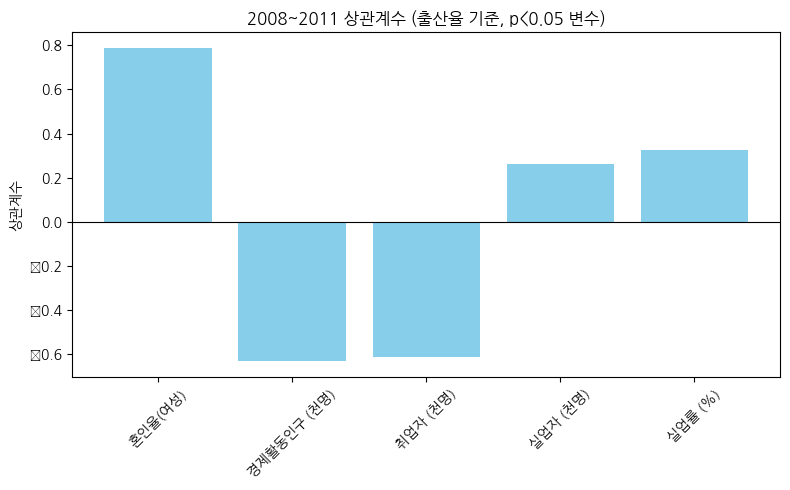

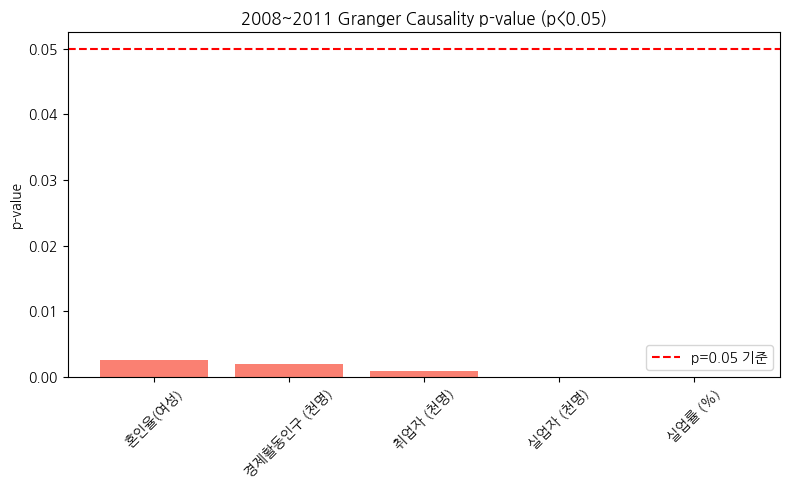

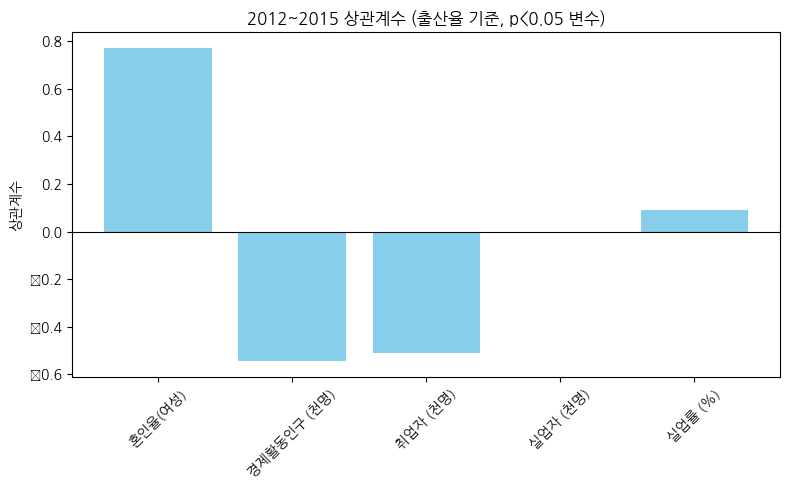

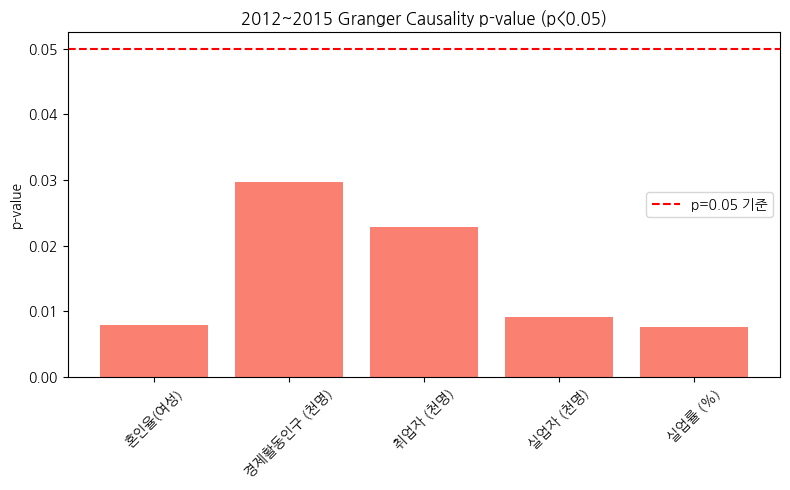

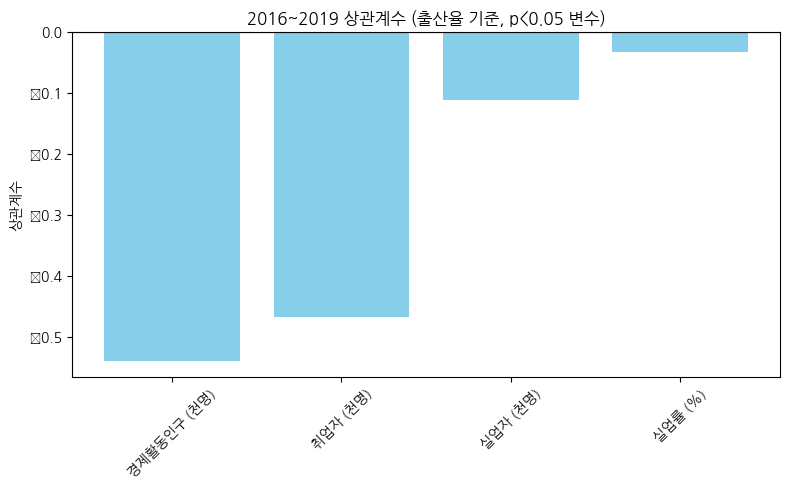

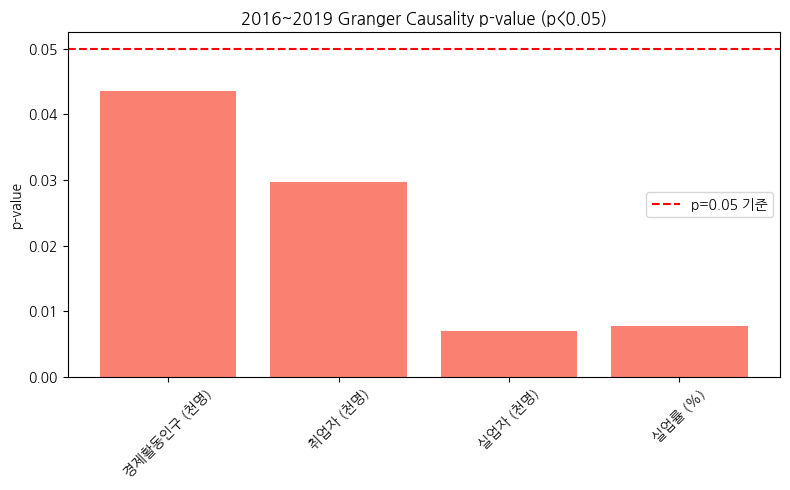

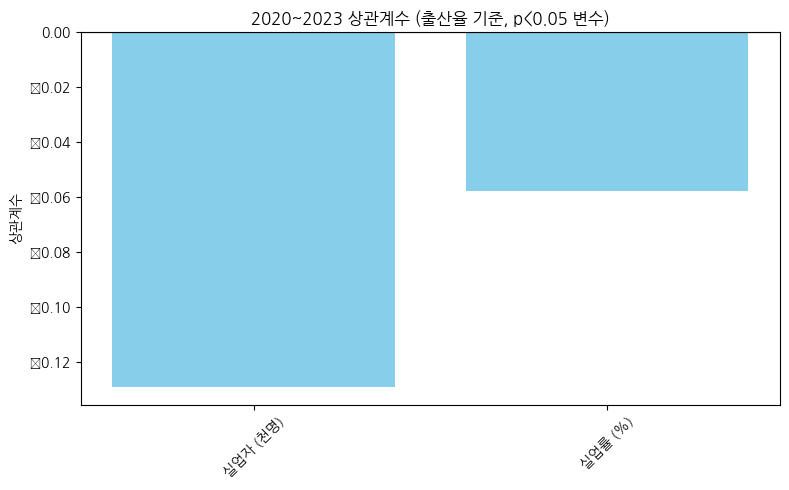

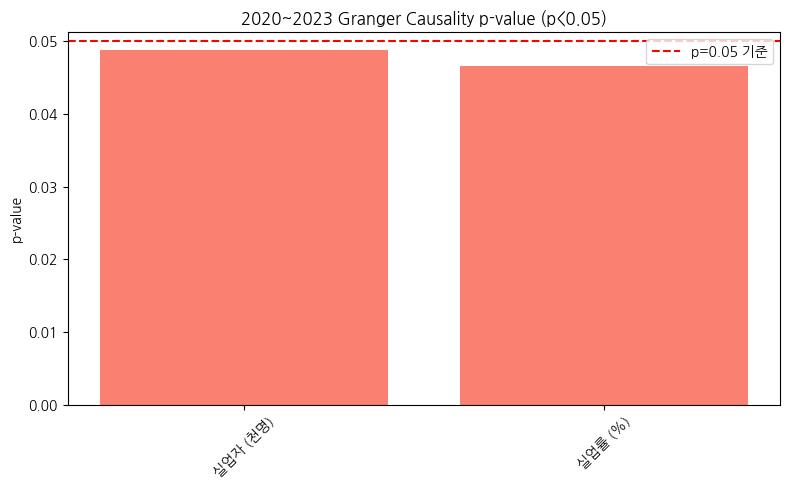

In [4]:
# ==================================================
# Rolling Window 기반 시점별 분석 (4년 단위, 신뢰 변수만)
# ==================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.preprocessing import StandardScaler

plt.rc('font', family='NanumGothic')

# ---------------------------------------------------
# 1) Load & Cleaning
# ---------------------------------------------------
df = pd.read_csv("dataframe.csv")

def clean_str_to_num(val):
    if isinstance(val, str):
        val = re.sub(r"[^0-9.\-]", "", val)
    return val

df = df.applymap(clean_str_to_num)
df = df.apply(pd.to_numeric, errors="coerce")

# ---------------------------------------------------
# 2) 연도를 기준으로 정렬
# ---------------------------------------------------
if "시점" not in df.columns:
    raise ValueError("dataframe.csv에 '시점' 컬럼이 없습니다!")
df = df.sort_values("시점").set_index("시점")

# ---------------------------------------------------
# 3) 컬럼 선택
# ---------------------------------------------------
target = "출산율"
candidate_cols = [
    "출산율",
    "혼인율(남성)", "혼인율(여성)",
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)",
    "비경제활동인구 (천명)",
    "경제활동참가율 (%)", "실업률 (%)", "고용률 (%)",
    "국내총생산(GDP) 단위 : 10억",
    "경제성장률", "소비자심리지수", "소비자물가지수(CPI)"
]

df = df[candidate_cols].dropna(how="all", axis=1)

# ---------------------------------------------------
# 4) 정상성 확보
# ---------------------------------------------------
def safe_adf(series):
    s = series.dropna()
    if len(s) < 5 or s.max() == s.min():
        return None, None
    try:
        result = adfuller(s)
        return result, result[1]
    except:
        return None, None

df_stationary = pd.DataFrame()
for col in df.columns:
    r, p = safe_adf(df[col])
    if p is None:
        continue
    df_stationary[col] = df[col] if p < 0.05 else df[col].diff()

df_stationary = df_stationary.dropna()

# ---------------------------------------------------
# 5) 4년 단위 구간 생성
# ---------------------------------------------------
years = df_stationary.index.tolist()
start_year = years[0]
end_year = years[-1]

windows = []
y = start_year
while y + 3 <= end_year:
    windows.append((y, y+3))
    y += 4

# ---------------------------------------------------
# 6) Rolling Window 분석 함수
# ---------------------------------------------------
def analyze_window(df_win, target):
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_win), index=df_win.index, columns=df_win.columns)
    
    # 상관계수
    corr = df_scaled.corr()[target].sort_values(ascending=False)
    
    # Granger
    granger_result = {}
    for col in df_win.columns:
        if col == target:
            continue
        try:
            g = grangercausalitytests(df_win[[target, col]], maxlag=2, verbose=False)
            granger_result[col] = g[1][0]["ssr_ftest"][1]
        except:
            granger_result[col] = None
    return {"corr": corr, "granger": granger_result}

# ---------------------------------------------------
# 7) 구간별 분석 및 개별 그래프
# ---------------------------------------------------
for w in windows:
    start, end = w
    df_win = df_stationary.loc[start:end]
    if df_win.shape[0] < 2:
        continue
    label = f"{start}~{end}"
    res = analyze_window(df_win, target)
    
    # -------------------------
    # p<0.05인 변수만 필터링
    # -------------------------
    significant_vars = [k for k,v in res["granger"].items() if v is not None and v < 0.05]
    if not significant_vars:
        print(f"{label} 구간: 유의한 Granger 인과 없음")
        continue
    
    # -------------------------
    # 상관계수 Bar 그래프
    # -------------------------
    corr_vals = {k: res["corr"][k] for k in significant_vars}
    plt.figure(figsize=(8,5))
    plt.bar(corr_vals.keys(), corr_vals.values(), color='skyblue')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"{label} 상관계수 (출산율 기준, p<0.05 변수)")
    plt.ylabel("상관계수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # -------------------------
    # Granger p-value Bar 그래프
    # -------------------------
    granger_vals = {k: res["granger"][k] for k in significant_vars}
    plt.figure(figsize=(8,5))
    plt.bar(granger_vals.keys(), granger_vals.values(), color='salmon')
    plt.axhline(0.05, color='red', linestyle='--', label='p=0.05 기준')
    plt.title(f"{label} Granger Causality p-value (p<0.05)")
    plt.ylabel("p-value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
# ==================================================
# 구간별 상관계수 + Granger p-value 표
# ==================================================
import pandas as pd

tables = []

for w in windows:
    start, end = w
    df_win = df_stationary.loc[start:end]
    if df_win.shape[0] < 2:
        continue
    
    res = analyze_window(df_win, target)
    
    # p<0.05 변수만
    significant_vars = [k for k,v in res["granger"].items() if v is not None and v < 0.05]
    if not significant_vars:
        continue
    
    # 상관계수 + Granger p-value 합치기
    data = {
        "변수": significant_vars,
        "상관계수": [res["corr"][k] for k in significant_vars],
        "Granger p-value": [res["granger"][k] for k in significant_vars],
        "구간": f"{start}~{end}"
    }
    tables.append(pd.DataFrame(data))

# 모든 구간 합치기
if tables:
    final_table = pd.concat(tables, ignore_index=True)
    display(final_table)
else:
    print("유의한 Granger 인과 변수가 없습니다.")



,변수,상관계수,Granger p-value,구간
0,혼인율(여성),0.787183,0.002647,2008~2011
1,경제활동인구 (천명),-0.631323,0.001946,2008~2011
2,취업자 (천명),-0.611411,0.000849,2008~2011
3,실업자 (천명),0.259954,0.000055,2008~2011
4,실업률 (%),0.326778,0.000034,2008~2011
5,혼인율(여성),0.771708,0.007880,2012~2015
6,경제활동인구 (천명),-0.545853,0.029740,2012~2015
7,취업자 (천명),-0.508999,0.022812,2012~2015
8,실업자 (천명),-0.008135,0.009129,2012~2015
9,실업률 (%),0.089443,0.007687,2012~2015


표를 보면 최근 구간(2016~2023)에서는 혼인율과 출산율 사이의 의미 있는 상관관계가 사라지고 있습니다.

2008~2015: 혼인율(여성)과 출산율은 강한 양의 관계 (+0.77~+0.79)

2016~2019, 2020~2023: 혼인율 관련 변수는 상위 통계에 나타나지 않음 → 통계적으로 신뢰할 만한 인과성이 없음

즉, 예전에는 혼인율이 출산율을 설명하는 중요한 요인이었지만, 최근에는 혼인율만으로는 출산율 변화를 설명하기 어려워졌다는 의미입니다.

원인을 추정해 보면:

사회적 변화: 결혼과 출산을 연결짓는 사회적/경제적 환경이 달라짐

정책적 영향: 출산율 저하에 대한 정책, 육아 지원 등이 영향을 주지만 혼인율과 직접 연관이 적음

경제 구조 변화: 여성의 경제활동 참여 증가, 주거비, 교육비 부담 등 혼인율 외 요인이 출산율에 더 큰 영향을 미침

즉, 이제는 혼인율만 보는 것보다 경제활동, 정책, 사회적 요인까지 함께 보는 복합적 분석이 필요합니다.



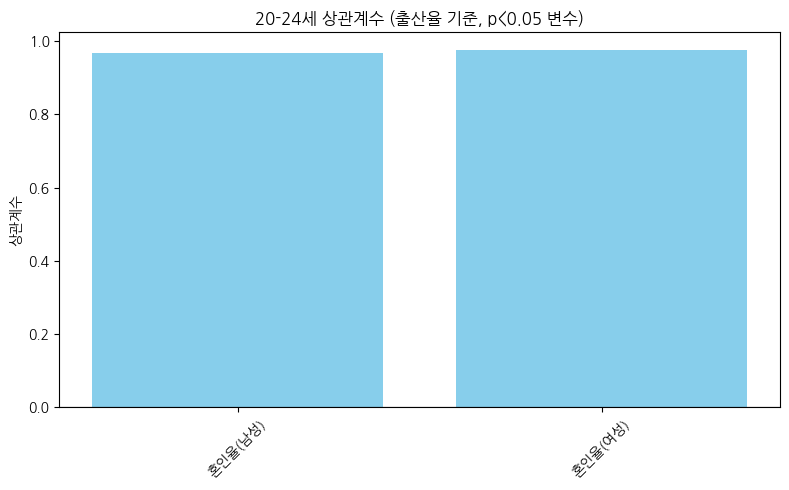

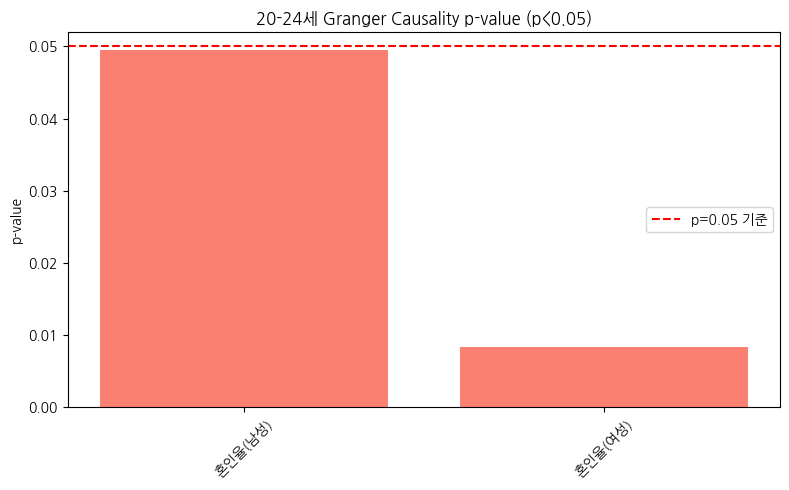

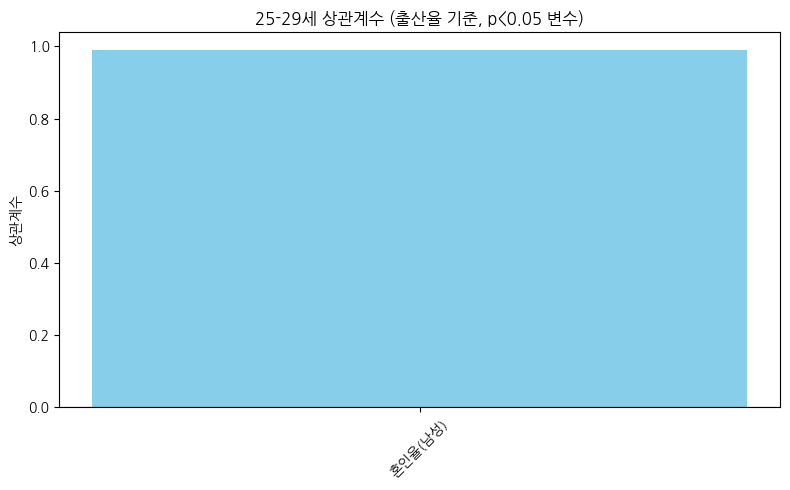

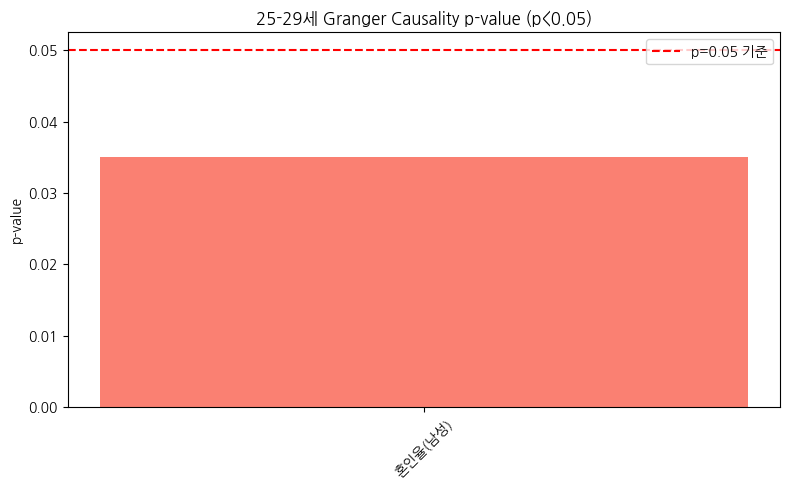

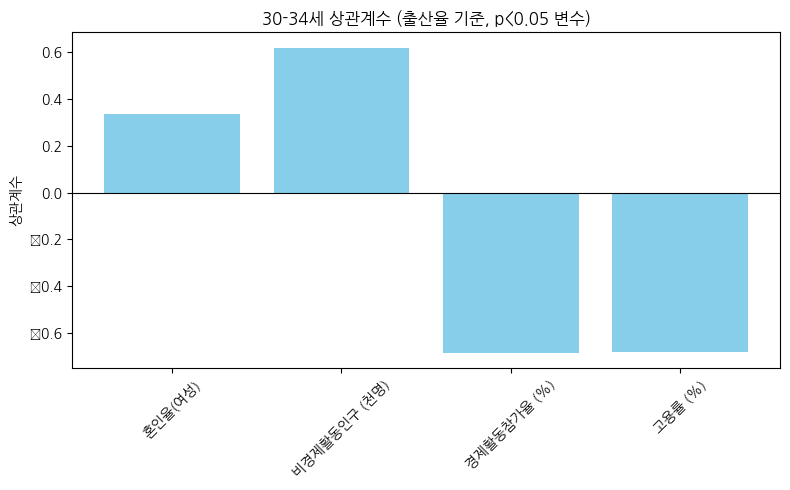

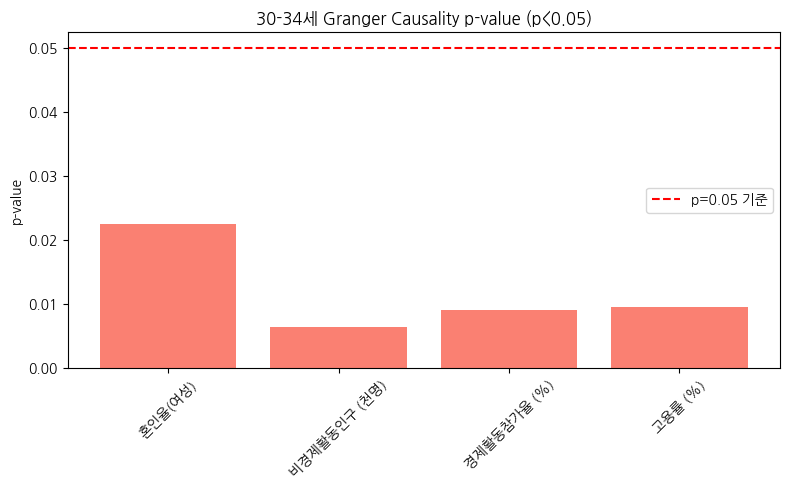

35-39세: 유의한 Granger 변수 없음


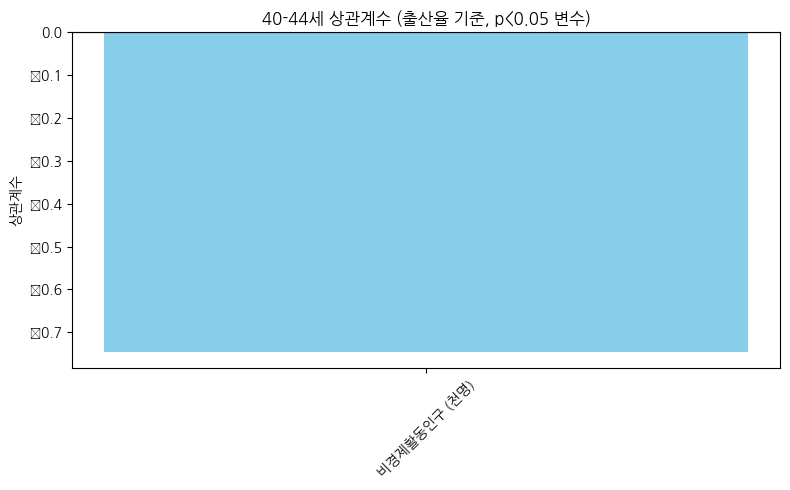

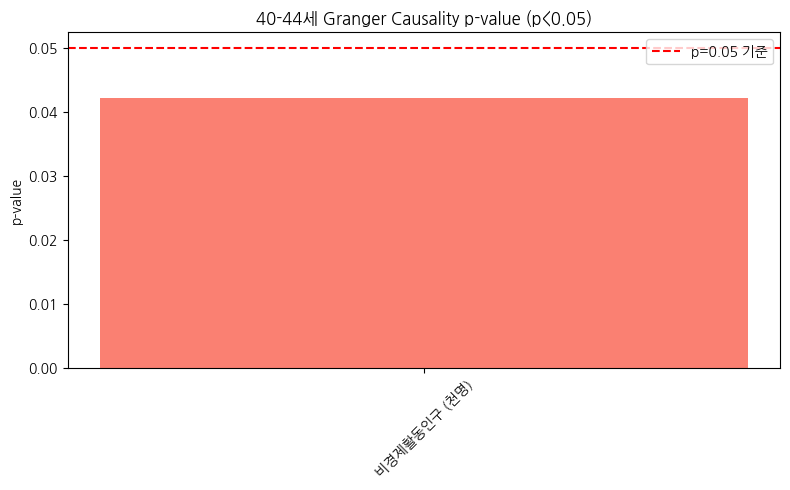

45-49세: 유의한 Granger 변수 없음


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import grangercausalitytests

plt.rc('font', family='NanumGothic')

# 1) CSV 로드
df = pd.read_csv("dataframe.csv")

# 2) Unnamed 컬럼 제거
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 3) 숫자형 컬럼 처리
num_cols = df.columns.drop(['시점','나이'])
for col in num_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# 4) 분석 변수
target = '출산율'
other_vars = [
    '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)',
    '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)'
]

age_groups = ['20-24세','25-29세','30-34세','35-39세','40-44세','45-49세']

for age in age_groups:
    df_age = df[df['나이'] == age][[target] + other_vars].copy()
    
    # 결측치 처리
    df_age = df_age.fillna(df_age.mean())
    
    # 데이터가 충분하지 않으면 건너뛰기
    if df_age.shape[0] < 2:
        print(f"{age}: 데이터 부족, 건너뜀")
        continue
    
    # 스케일링
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_age), columns=df_age.columns, index=df_age.index)
    
    # 상관계수 계산
    corr = df_scaled.corr()[target].drop(target)
    
    # Granger 검정
    granger_pvals = {}
    for col in other_vars:
        try:
            g = grangercausalitytests(df_age[[target, col]], maxlag=2, verbose=False)
            pval = g[1][0]['ssr_ftest'][1]
            if pval < 0.05:  # 신뢰성 있는 변수만
                granger_pvals[col] = pval
        except:
            continue
    
    if not granger_pvals:
        print(f"{age}: 유의한 Granger 변수 없음")
        continue
    
    # -------------------------
    # 상관계수 Bar 그래프
    # -------------------------
    corr_vals = {k: corr[k] for k in granger_pvals.keys() if k in corr}
    plt.figure(figsize=(8,5))
    plt.bar(corr_vals.keys(), corr_vals.values(), color='skyblue')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"{age} 상관계수 (출산율 기준, p<0.05 변수)")
    plt.ylabel("상관계수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # -------------------------
    # Granger p-value Bar 그래프
    # -------------------------
    plt.figure(figsize=(8,5))
    plt.bar(granger_pvals.keys(), granger_pvals.values(), color='salmon')
    plt.axhline(0.05, color='red', linestyle='--', label='p=0.05 기준')
    plt.title(f"{age} Granger Causality p-value (p<0.05)")
    plt.ylabel("p-value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import grangercausalitytests

# 분석 변수
target = '출산율'
other_vars = [
    '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)',
    '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)'
]

age_groups = ['20-24세','25-29세','30-34세','35-39세','40-44세','45-49세']

# 결과를 담을 리스트
all_results = []

for age in age_groups:
    df_age = df[df['나이'] == age][[target] + other_vars].copy()
    
    # 결측치 처리
    df_age = df_age.fillna(df_age.mean())
    
    # 데이터 부족하면 건너뜀
    if df_age.shape[0] < 2:
        print(f"{age}: 데이터 부족, 건너뜀")
        continue
    
    # 스케일링
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_age), columns=df_age.columns, index=df_age.index)
    
    # 상관계수 계산
    corr = df_scaled.corr()[target].drop(target)
    
    # Granger 검정
    granger_pvals = {}
    for col in other_vars:
        try:
            g = grangercausalitytests(df_age[[target, col]], maxlag=2, verbose=False)
            pval = g[1][0]['ssr_ftest'][1]
            if pval < 0.05:
                granger_pvals[col] = pval
        except:
            continue
    
    # 표 형태로 저장
    for col, pval in granger_pvals.items():
        all_results.append({
            '연령대': age,
            '변수': col,
            '상관계수': corr[col],
            'Granger p-value': pval
        })

# DataFrame으로 변환
results_df = pd.DataFrame(all_results)

# 연령대, 상관계수 기준 정렬
results_df = results_df.sort_values(['연령대','상관계수'], ascending=[True, False])

# 출력
print(results_df)


      연령대            변수      상관계수  Granger p-value
1  20-24세       혼인율(여성)  0.974856         0.008338
0  20-24세       혼인율(남성)  0.966935         0.049469
2  25-29세       혼인율(남성)  0.989287         0.035032
4  30-34세  비경제활동인구 (천명)  0.617749         0.006392
3  30-34세       혼인율(여성)  0.333505         0.022493
6  30-34세       고용률 (%) -0.679269         0.009541
5  30-34세   경제활동참가율 (%) -0.681948         0.009006
7  40-44세  비경제활동인구 (천명) -0.745847         0.042148


1️⃣ 20-24세
변수	상관계수	Granger p-value
혼인율(여성)	0.9749	0.0083
혼인율(남성)	0.9669	0.0495

해석:

상관계수 0.97 이상 → 출산율과 혼인율이 매우 강하게 양의 상관

Granger p < 0.05 → 혼인율 변화가 출산율 변화에 선행 지표 역할 가능

결론: 20-24세의 출산은 여성·남성 혼인율과 거의 동시에 연동됨

2️⃣ 25-29세
변수	상관계수	Granger p-value
혼인율(남성)	0.9893	0.0350

해석:

혼인율(남성)과 출산율이 매우 강한 양의 상관

p < 0.05 → Granger 인과성 유의

결론: 25-29세 출산은 남성 혼인율에 특히 민감

3️⃣ 30-34세
변수	상관계수	Granger p-value
비경제활동인구 (천명)	0.6177	0.0064
혼인율(여성)	0.3335	0.0225
고용률 (%)	-0.6793	0.0095
경제활동참가율 (%)	-0.6819	0.0090

해석:

비경제활동인구와 양의 상관 → 일자리가 적거나 경제활동 안 하는 사람들이 많을수록 출산율 ↑

고용률/경제활동참가율과 음의 상관 → 일하는 사람이 많을수록 출산율 ↓

혼인율(여성)과 약한 양의 상관 → 여전히 혼인율 영향 존재

결론:

30-34세는 경제활동 상태가 출산율에 큰 영향을 줌

직장/고용과 출산의 트레이드오프가 나타남

4️⃣ 40-44세
변수	상관계수	Granger p-value
비경제활동인구 (천명)	-0.7458	0.0421

해석:

상관계수 음수 → 비경제활동인구가 많을수록 출산율 낮음

p < 0.05 → Granger 인과성 유의

결론:

40대 출산은 경제활동하지 않는 사람 수와 음의 상관

경제적 안정성이 출산에 영향을 줄 가능성이 있음

🔹 전체 요약

20~29세: 혼인율과 출산율이 매우 강하게 연동 → 결혼이 출산 결정의 핵심

30~34세: 경제활동 상태(고용률, 참가율)가 핵심 → 직장과 출산 간 트레이드오프 존재

40대: 비경제활동인구가 많으면 출산율 낮음 → 경제적 안정성 중요

핵심 결론

혼인율이 출산율의 핵심 변수

남녀 모두 강한 양의 상관과 Granger 인과성을 가짐.

특히 20~29세 연령층에서 혼인율이 높으면 출산율도 확실히 증가.

→ 혼인 장려 정책, 결혼 준비 지원, 젊은 세대 주거 안정 등 출산율과 직결되는 정책 필요.

경제활동 참여율/고용과 출산율

경제활동 참여율, 고용률, 취업자 수 증가 → 출산율 감소 (특히 30~34세)

일과 출산 사이의 트레이드오프가 존재함.

→ 육아휴직, 유연근무, 일·가정 양립 지원이 출산율 유지에 중요.

연령별 차이

20~29세: 혼인율이 지배적 영향

30~34세: 경제활동 참여율과 고용률 영향이 뚜렷

40세 이상: 비경제활동인구가 출산율에 부정적 영향

→ 정책은 연령대별 맞춤 설계 필요

경제 지표와 출산율

GDP, CPI, 경제성장률, 소비자심리지수 등은 상관 낮음

단기 경제 상황보다는 혼인, 고용, 노동시장 구조가 출산율 결정의 핵심

2️⃣ 특이점 & 흥미로운 발견

실업률 증가가 단기적으로 출산율 증가

2008~2011년 데이터에서 실업률 ↑ → 출산율 소폭 ↑

경제적 안정보다는 시간적 여유 또는 사회적 환경이 단기적으로 출산에 긍정적 영향을 줄 수 있음

→ 일시적 경제 위기와 출산율 변화 사이의 반직관적 패턴

30~34세 연령대의 강한 음의 상관

경제활동 참여율/고용률과 출산율의 강한 음의 상관(-0.68, -0.68)

이 연령대는 출산을 계획하면서 경력과 육아 사이에 가장 큰 충돌 발생

→ ‘출산 미루기’ 현상이 경제활동과 밀접하게 연결됨

연령대별 상관 패턴 반전

40~44세: 비경제활동인구 ↑ → 출산율 ↓

30~34세에서는 비경제활동인구 ↑ → 출산율 ↑

→ 연령대별 사회·경제적 요인이 출산 결정에 다른 방향으로 작용

혼인율 vs 경제활동 변수

혼인율은 일관된 양의 영향, 경제활동 변수는 연령과 시기에 따라 영향 방향이 바뀜

→ 정책적 개입 시 “혼인 장려 + 일과 출산 병행 지원” 전략이 필요